In [1]:
import sys
print(sys.version)


3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [3]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 4.6 MB/s eta 0:08:50
     ---------------------------------------- 0.0/2.4 GB 6.8 MB/s eta 0:05:59
     ---------------------------------------- 0.0/2.4 GB 8.8 MB/s eta 0:04:40
     ---------------------------------------- 0.0/2.4 GB 10.2 MB/s eta 0:04:01
     ---------------------------------------- 0.0/2.4 GB 10.8 MB/s eta 0:03:47
     ---------------------------------------- 0.0/2.4 GB 9.0 MB/s eta 0:04:31
     ---------------------------------------- 0.0/2.4 GB 8.6 MB/s eta 0:04:44
     ---------------------------------------- 0.0/2.4 GB 7.6 MB/s eta 0:05:24
     ---------------------------------------- 0.0/2.4 GB 7.5 MB/s eta 0:05:26
     ---------------------------------------- 0.0/2.4 GB 7.0 MB/s eta 0:05:48
     -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [6]:
!pip install ultralytics

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     -------------------------------------- - 51.2/52.8 kB 1.3 MB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 906.3 kB/s eta 0:00:00
  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 61.0/61.0 kB 3.2 MB/s eta 0:00:00
  Using cached ultralytics_thop-2.0.19-py3-none-any.whl.metadata (14 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/121.0 kB ? eta -:--:--
     -------------------------------------- 121.0/121.0 kB 3.6 MB/s eta 0:00:00
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------- -------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import zipfile

zip_path = r"C:\Users\ASUS\Downloads\archive.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted")

Dataset Extracted


In [8]:
import os

for root, dirs, files in os.walk("dataset"):
    print(root)

dataset
dataset\images
dataset\images\test
dataset\images\train
dataset\images\val
dataset\labels
dataset\labels\test
dataset\labels\train
dataset\labels\val


In [9]:
classes = set()

import os

label_path = "dataset/labels/train"

for file in os.listdir(label_path):
    with open(os.path.join(label_path, file), "r") as f:
        lines = f.readlines()

        for line in lines:
            class_id = line.split()[0]
            classes.add(class_id)

print("Classes found:", classes)

Classes found: {'0', '1', '2'}


In [10]:
import os
print(os.path.exists("data.yaml"))

True


In [11]:
import torch

print(torch.cuda.is_available())

True


In [13]:
from ultralytics import YOLO

model = YOLO("yolov11n.pt")

model.train(
    data=r"C:\Users\ASUS\OneDrive\Desktop\extracted\data.yaml",
    epochs=20,
    imgsz=640
)

FileNotFoundError: [Errno 2] No such file or directory: 'yolov11n.pt'

In [12]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

results = model.train(
    data="data.yaml",
    epochs=10,
    imgsz=416,
    batch=16,
    workers=8,
    device=0
)

Ultralytics 8.4.57  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience

In [2]:
from ultralytics import YOLO

model = YOLO(r"C:\Users\ASUS\runs\detect\train-3\weights\best.pt")

metrics = model.val(data="data.yaml")

Ultralytics 8.4.57  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
YOLO11n summary (fused): 101 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 692.3463.9 MB/s, size: 241.1 KB)
val: Scanning C:\Users\ASUS\dataset\labels\val.cache... 2438 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2438/2438  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 153/153 4.1it/s 37.8s0.2ss
                   all       2438      21032      0.823      0.769      0.824      0.488
                helmet       1782       6586      0.909      0.823      0.885       0.56
                  vest        406        870      0.751      0.711      0.782       0.51
                  head        712      13576       0.81      0.773      0.804      0.394
Speed: 1.2ms preprocess, 4.4ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to C:\Users

In [4]:
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

mAP50: 0.8236785973591422
mAP50-95: 0.48795761664571796
Precision: 0.8233358064150352
Recall: 0.7690188135775444


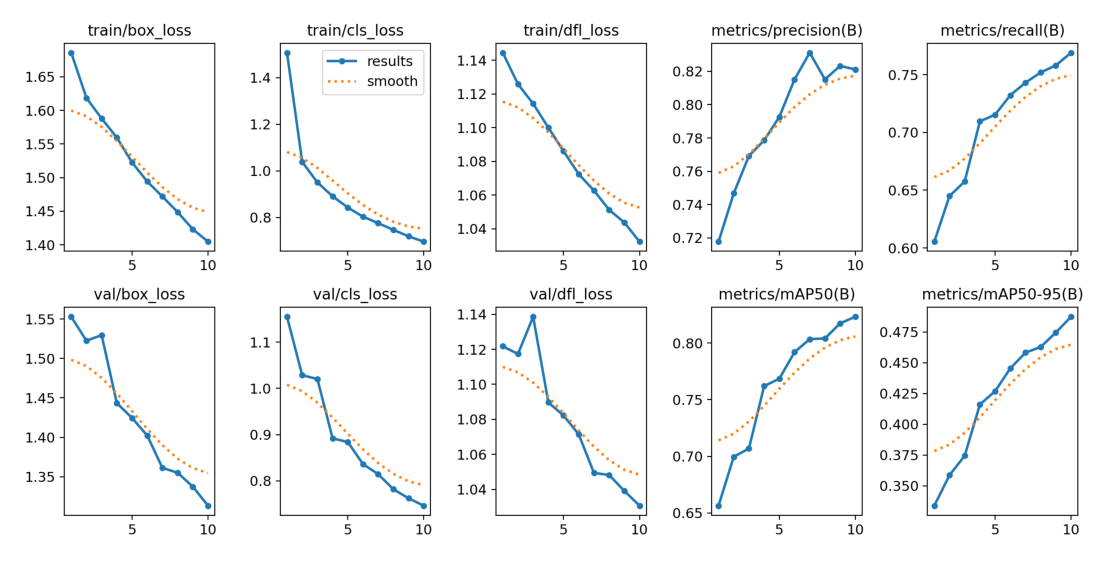

In [5]:
%matplotlib inline
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(r"C:\Users\ASUS\runs\detect\train-3\results.png")

plt.figure(figsize=(14,10))
plt.imshow(img)
plt.axis("off")
plt.show()

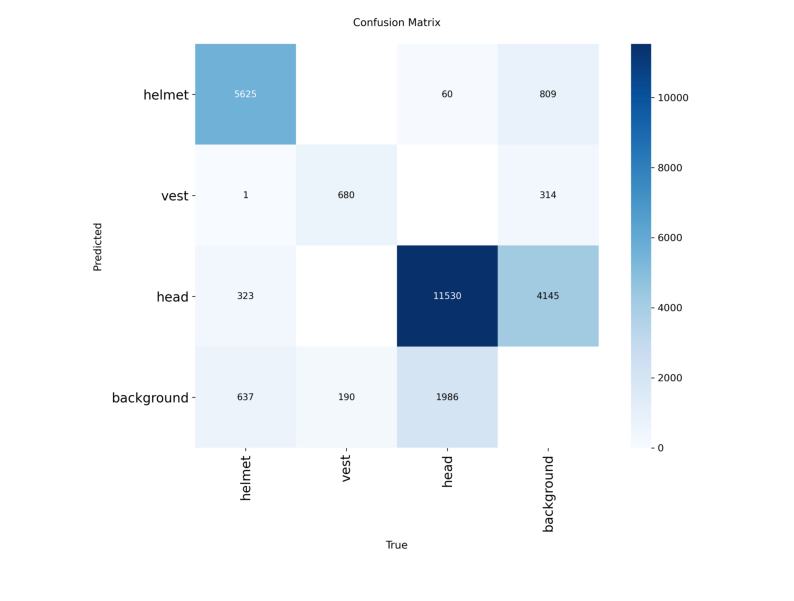

In [6]:
img = Image.open(r"C:\Users\ASUS\runs\detect\train-3\confusion_matrix.png")

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [7]:
import os

files = os.listdir(r"C:\Users\ASUS\runs\detect\train-3")

for file in files:
    print(file)

args.yaml
BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


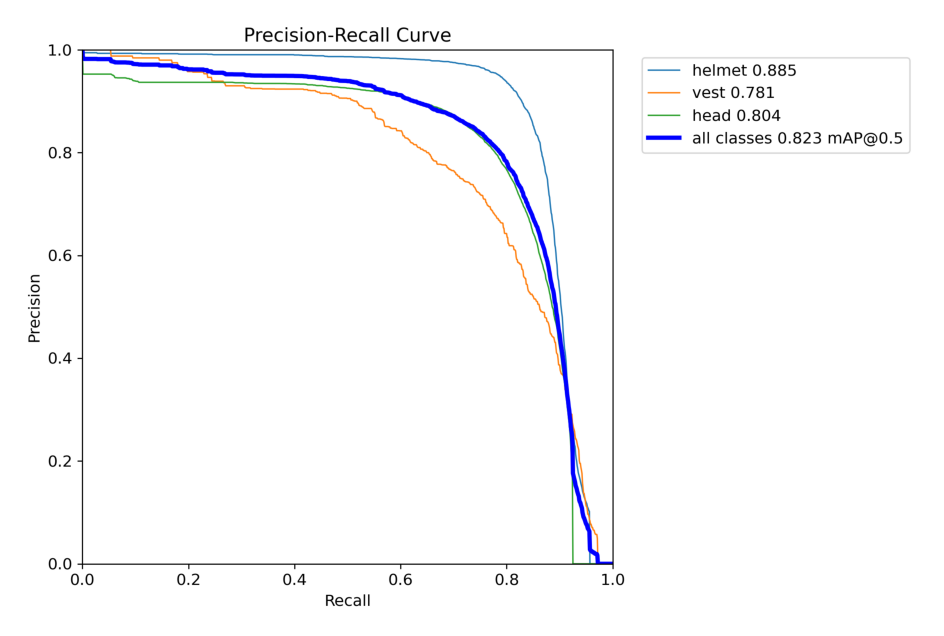

In [8]:
img = Image.open(r"C:\Users\ASUS\runs\detect\train-3\BoxPR_curve.png")

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")
plt.show()

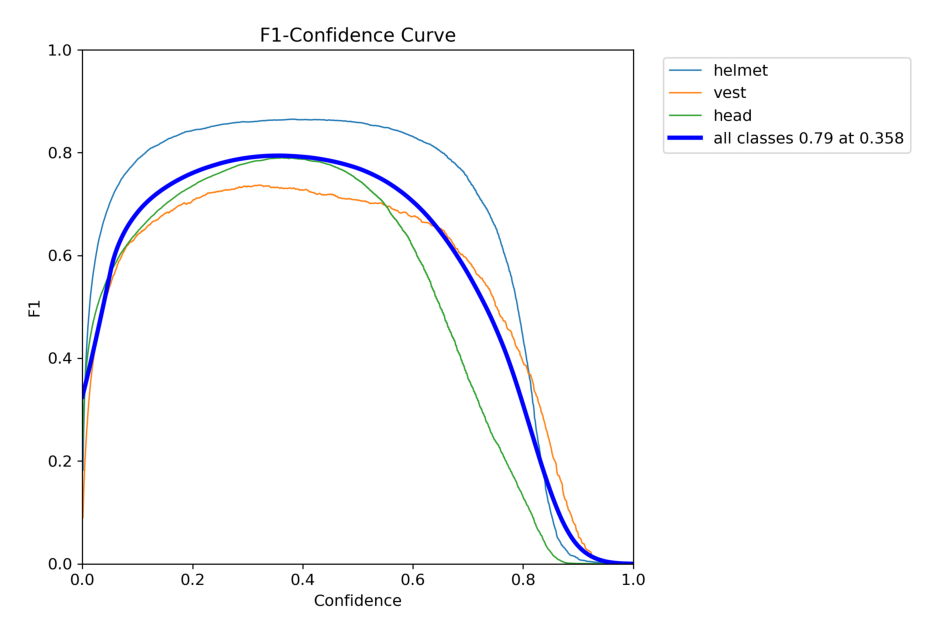

In [9]:
img = Image.open(r"C:\Users\ASUS\runs\detect\train-3\BoxF1_curve.png")

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")
plt.show()

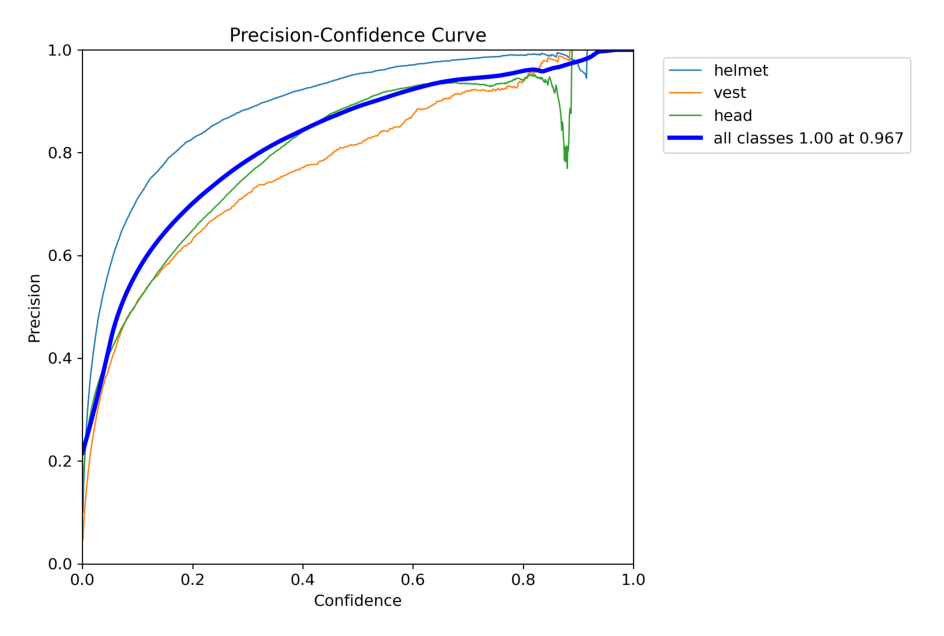

In [31]:
img = Image.open(r"C:\Users\ASUS\runs\detect\train-3\BoxP_curve.png")

plt.figure(figsize=(12,8))
plt.imshow(img)
plt.axis("off")
plt.show()

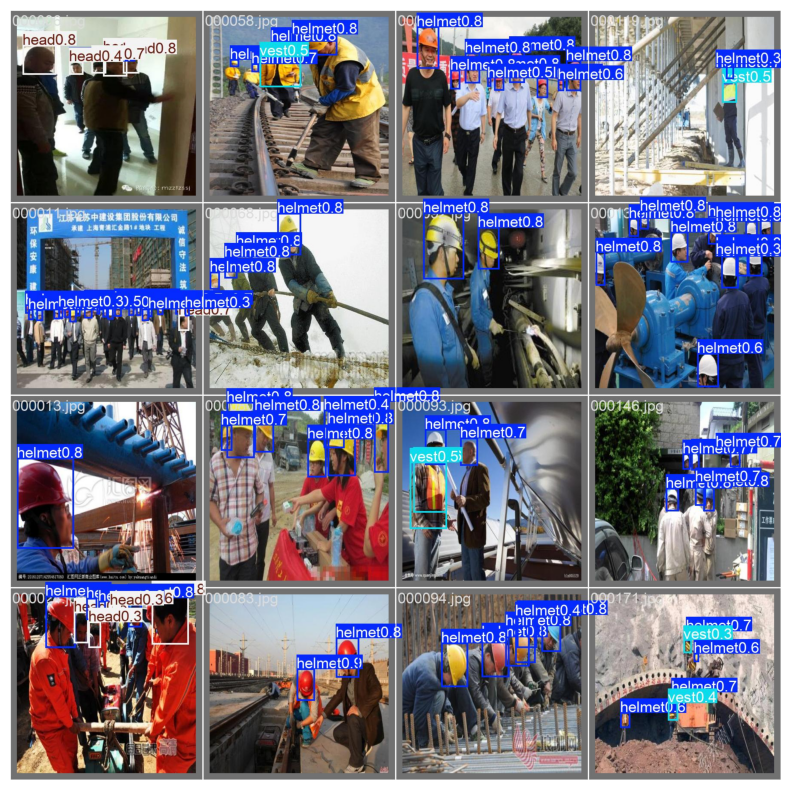

In [10]:
img = Image.open(r"C:\Users\ASUS\runs\detect\train-3\val_batch0_pred.jpg")

plt.figure(figsize=(14,10))
plt.imshow(img)
plt.axis("off")
plt.show()


0: 640x640 4 -s, 4 helmet - v2 2024-02-21 10-37ams, 72.3ms
Speed: 24.0ms preprocess, 72.3ms inference, 4.0ms postprocess per image at shape (1, 3, 640, 640)


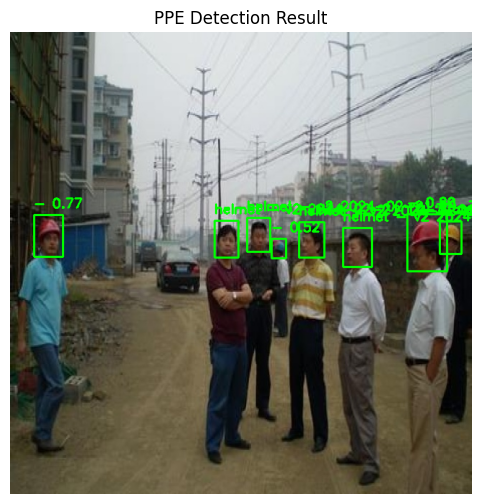

In [4]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load trained model
model = YOLO(r"C:\Users\ASUS\runs\detect\train\weights\best.pt")

# Load image (USE PERMANENT PATH, NOT TEMP)
image_path = r"C:\Users\ASUS\AppData\Local\Temp\0e1c9a3d-9f59-42bf-b669-10fc61f36eae_archive.zip.eae\images\test\005886.jpg"
frame = cv2.imread(image_path)

# Safety check
if frame is None:
    print("❌ Image not found! Check file path.")
    exit()

# Run detection
results = model(frame)

# Get class names
names = model.names

# Draw detections
for result in results:
    for box in result.boxes:

        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        cls = int(box.cls[0])
        label = names[cls]

        # 🎯 Proper logic (IMPORTANT FIX)
        if "no_helmet" in label.lower() or "no_vest" in label.lower():
            color = (0, 0, 255)   # RED (unsafe)
        else:
            color = (0, 255, 0)   # GREEN (safe)

        # Draw box
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

        # Draw label
        cv2.putText(
            frame,
            f"{label} {conf:.2f}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

# 🖼 Convert BGR → RGB for display (Jupyter safe)
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.axis("off")
plt.title("PPE Detection Result")
plt.show()


0: 640x640 4 -s, 4 helmet - v2 2024-02-21 10-37ams, 71.1ms
Speed: 36.6ms preprocess, 71.1ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 640)


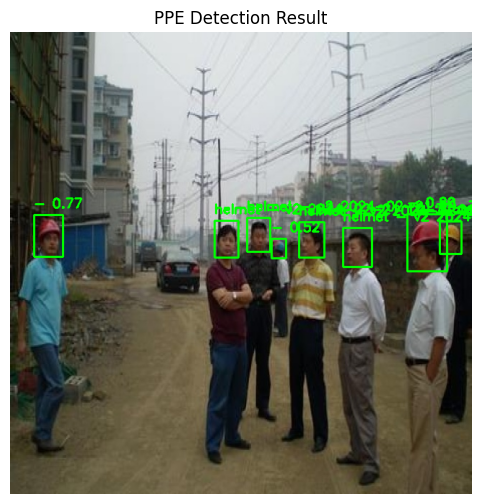

In [3]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load model
model = YOLO(r"C:\Users\ASUS\runs\detect\train\weights\best.pt")

# Image path
image_path = r"C:\Users\ASUS\AppData\Local\Temp\0e1c9a3d-9f59-42bf-b669-10fc61f36eae_archive.zip.eae\images\test\005886.jpg"
frame = cv2.imread(image_path)

if frame is None:
    print("❌ Image not found!")
    exit()

results = model(frame)
names = model.names

for result in results:
    for box in result.boxes:

        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        cls = int(box.cls[0])
        label = names[cls].lower()

        # ----------------------------
        # CASE 1: NO HELMET → RED + ALERT
        # ----------------------------
        if "no helmet" in label or "no_helmet" in label:
            color = (0, 0, 255)  # RED
            text = f"🚨 ALERT! NO HELMET {conf:.2f}"

        # ----------------------------
        # CASE 2: NO VEST → NORMAL BOX (NO ALERT)
        # ----------------------------
        elif "no vest" in label or "no_vest" in label:
            color = (255, 255, 0)  # CYAN/YELLOW (normal warning)
            text = f"NO VEST {conf:.2f}"

        # ----------------------------
        # CASE 3: SAFE (helmet + vest)
        # ----------------------------
        else:
            color = (0, 255, 0)  # GREEN
            text = f"{label} {conf:.2f}"

        # Draw box
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

        # Draw text
        cv2.putText(
            frame,
            text,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

# Show output
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.axis("off")
plt.title("PPE Detection Result")
plt.show()

In [2]:
cv2.imwrite("ppe_result.jpg", frame)
print("✅ Result saved as ppe_result.jpg")

✅ Result saved as ppe_result.jpg



image 1/1 C:\Users\ASUS\AppData\Local\Temp\7c665755-c659-4261-9e68-24cefd134165_archive.zip.165\images\test\001110.jpg: 416x416 3 helmets, 29.3ms
Speed: 3.8ms preprocess, 29.3ms inference, 4.2ms postprocess per image at shape (1, 3, 416, 416)
Results saved to C:\Users\ASUS\runs\detect\predict-4


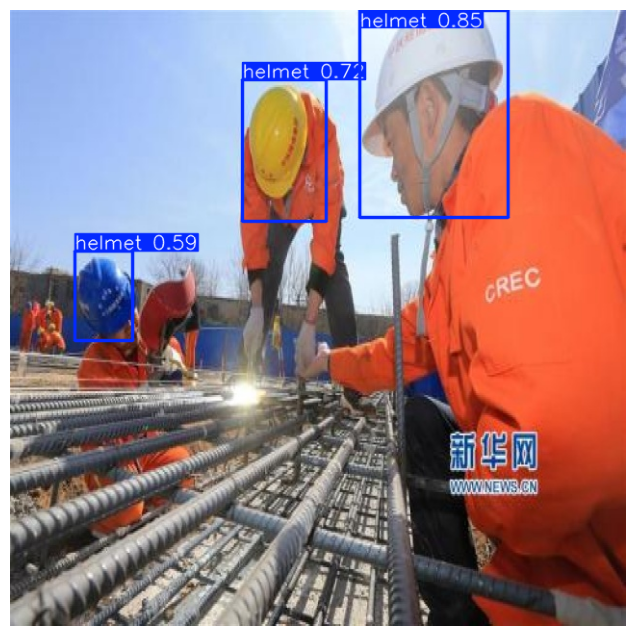

In [8]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

model = YOLO(r"C:\Users\ASUS\runs\detect\train-3\weights\best.pt")

results = model.predict(
    source=r"C:\Users\ASUS\AppData\Local\Temp\7c665755-c659-4261-9e68-24cefd134165_archive.zip.165\images\test\001110.jpg",
    save=True,
    conf=0.25
)

img = results[0].plot()

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

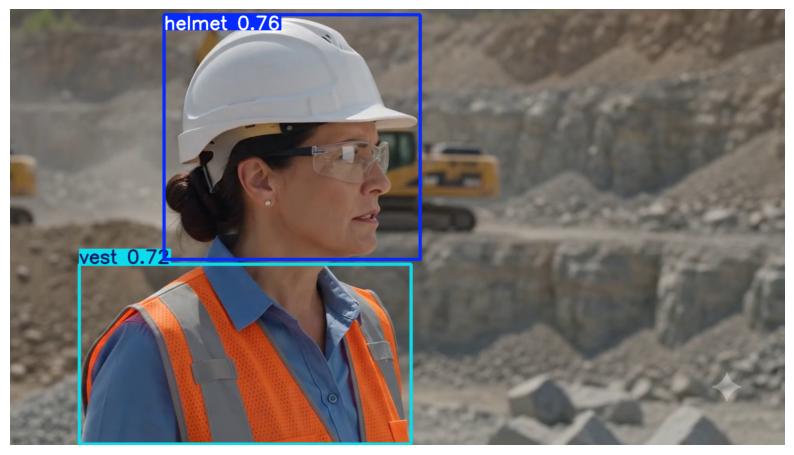

In [2]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Load model
model = YOLO(r"C:\Users\ASUS\runs\detect\train-3\weights\best.pt")

video_path = r"C:\Users\ASUS\Downloads\vid1.mp4"
cap = cv2.VideoCapture(video_path)

# 🎛️ SPEED CONTROL (change this value)
speed_factor = 0.5 
# 1.0 = normal speed
# 0.5 = 2x faster
# 2.0 = 2x slower
# 0 = max speed (no delay)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model(frame)
    annotated_frame = results[0].plot()

    frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    clear_output(wait=True)
    plt.figure(figsize=(10, 6))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

    # ⏱️ dynamic speed control
    time.sleep(max(0, speed_factor * 0.03))  # base delay = 0.03 sec

cap.release()

In [ ]:
from ultralytics import YOLO
import cv2
import time

# Load model
model = YOLO(r"C:\Users\ASUS\runs\detect\train-3\weights\best.pt")

# Try camera (auto fallback)
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    cap = cv2.VideoCapture(1)

# Set resolution
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 480)

prev_time = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # ⚡ Faster inference settings
    results = model.predict(
        frame,
        imgsz=640,
        conf=0.4,
        verbose=False
    )

    frame = results[0].plot()

    # FPS calculation
    curr_time = time.time()
    fps = 1 / (curr_time - prev_time)
    prev_time = curr_time

    # Show FPS on screen
    cv2.putText(
        frame,
        f"FPS: {int(fps)}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    # Display
    cv2.imshow("🔥 PPE Detection System (PRO)", frame)

    # Quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

In [ ]:
from ultralytics import YOLO
import cv2

model = YOLO(r"C:\Users\ASUS\runs\detect\train-3\weights\best.pt")

url = "http://192.168.1.4:8080/video"

cap = cv2.VideoCapture(url)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    results = model(frame)
    frame = results[0].plot()

    cv2.imshow("Phone Camera PPE Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()